# Cement Strength Prediction using Machine Learning

This project uses a machine learning model to predict the strength of cement based on its composition and other input features.

The model is trained on a dataset containing various material components and is used to estimate optimal combinations for better strength.

This was developed as a team project, where data collection and some visualization components were handled collaboratively.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

The dataset contains different features such as cement, water, aggregates, and age, which influence the strength of concrete.

The data is loaded and prepared for training the machine learning model.

In [2]:
url="https://drive.google.com/uc?id=1XnQHdX3sF1bJWCEWJufuY8qOPxAL1Xtq"
df=pd.read_csv(url)
df.head()


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


The dataset is preprocessed by selecting relevant features and splitting it into training and testing sets.

Feature scaling is applied using StandardScaler to improve model performance.

In [3]:
x = df[['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age']]
y = df['strength']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=50) # Splitting dataset into training and testing sets

In [4]:
scaler = StandardScaler()                                                                 # Scaling features to improve model performance
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

A Gradient Boosting Regressor model is used to learn the relationship between input features and cement strength.

The model is trained on the processed dataset to make accurate predictions.

In [5]:
model = GradientBoostingRegressor(random_state=50)                                        # Training Gradient Boosting model
model.fit(x_train_scaled, y_train)

GradientBoostingRegressor(random_state=50)

The model's performance is evaluated using metrics such as R² Score and Mean Squared Error (MSE).

These metrics help determine how well the model predicts cement strength.

In [6]:
y_pred = model.predict(x_test_scaled)                                                    # Predicting on test data
r2 = r2_score(y_test, y_pred)
error = mean_squared_error(y_test, y_pred)

print(f"Model R² Score: {r2:.3f}")
print(f"Mean Squared Error: {error:.3f}")

Model R² Score: 0.923
Mean Squared Error: 23.619


The trained model is used to generate and evaluate different cement compositions.

Based on predictions, optimal compositions are identified for achieving better strength.

In [7]:
ingredient_ranges = {"cement": (102, 540),"slag": (0, 359),"ash": (0, 200),"water": (122, 247),"superplastic": (0, 32.2),"coarseagg": (801, 1150),"fineagg": (594, 993),"age": (1, 365)}

num_samples = 1000
np.random.seed(50)                                                                      # Generating candidate compositions for optimization
candidates = pd.DataFrame({
    key: np.random.uniform(low, high, num_samples)
    for key, (low, high) in ingredient_ranges.items()
})

In [8]:
candidates_scaled = scaler.transform(candidates)
candidates["predicted_strength"] = model.predict(candidates_scaled)

In [9]:
# Sources:
# 1. European Commission JRC (2023): "Circular use of construction and demolition waste: Recycled aggregates"
#    https://publications.jrc.ec.europa.eu/repository/bitstream/JRC131294/JRC131294_01.pdf
# 2. MDPI Buildings (2024): "Recycled concrete aggregate (RCA) and performance effects"
#    https://www.mdpi.com/2412-3811/10/8/213

reuseability_score = {"cement":0.30,"slag":0.80,"ash":0.85,"water":0.20,"superplastic":0.40,"coarseagg":0.90,"fineagg":0.88}

mass_sum = candidates[list(reuseability_score.keys())].sum(axis=1)
candidates["reusability"] = (sum(candidates[col] * reuseability_score[col] for col in reuseability_score) / mass_sum).round(6)


In [10]:
feature_cols = ['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age']
cands_scaled = scaler.transform(candidates[feature_cols])
candidates["predicted_strength"] = model.predict(cands_scaled)                                         # Selecting best compositions based on predicted strength


In [11]:
obj_matrix = np.vstack([
    -candidates['predicted_strength'].to_numpy(float),
    -candidates['reusability'].to_numpy(float),
    candidates['cement'].to_numpy(float)
]).T

n = len(candidates)
is_dominated = np.zeros(n, dtype=bool)
EPS = 1e-12

for i in range(n):
    if is_dominated[i]: continue
    for j in range(n):
        if i == j: continue
        if np.all(obj_matrix[j] <= obj_matrix[i] + EPS) and np.any(obj_matrix[j] < obj_matrix[i] - EPS):
            is_dominated[i] = True
            break

pareto_df = candidates.loc[~is_dominated].copy().reset_index(drop=True)

pareto_df['predicted_strength'] = pareto_df['predicted_strength'].round(4)
pareto_df['reusability'] = pareto_df['reusability'].round(6)
pareto_df['cement'] = pareto_df['cement'].round(4)

top_10 = pareto_df.sort_values(
    by=['predicted_strength','reusability'],
    ascending=[False, False]
).head(10).reset_index(drop=True)

top_10_display = top_10.round(2)
print("Top 10 Pareto non-dominated mixes (strength ↑, reusability ↑, cement ↓):")
print(top_10_display)

top_10_display.to_csv("top_10_pareto_mixes.csv", index=False)
print("\nSaved only: top_10_pareto_mixes.csv (final result file)")


Top 10 Pareto non-dominated mixes (strength ↑, reusability ↑, cement ↓):
   cement    slag     ash   water  superplastic  coarseagg  fineagg     age  \
0  333.10  335.09  171.54  144.26         29.57    1122.74   776.26  254.27   
1  284.89  325.46   45.97  147.96         28.72    1127.93   824.80  242.51   
2  196.02  355.01    9.16  147.12         29.19    1142.33   719.56   70.48   
3  221.63  162.39   52.66  133.51         24.07    1145.34   799.11  325.94   
4  230.20  346.07  101.78  123.72         14.28    1016.17   878.89  107.52   
5  175.58  234.84  119.15  146.57         15.01    1008.79   692.54  226.20   
6  109.18  342.72  175.51  143.38         24.74    1125.40   943.44  218.05   
7  104.87  181.40  190.85  133.50         24.20     939.73   767.22   92.49   
8  104.70  331.03  180.98  138.89         24.34    1033.76   595.91  339.89   
9  105.00  256.98   20.22  126.13         15.92    1140.34   990.20  200.74   

   predicted_strength  reusability  
0               96.3

Various graphs and visualizations are used to better understand the data and model performance.

This part of the project was implemented collaboratively.

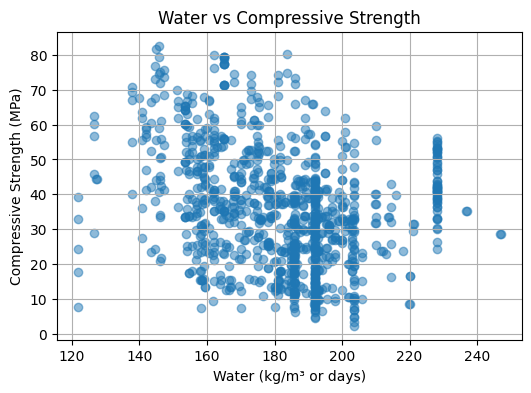

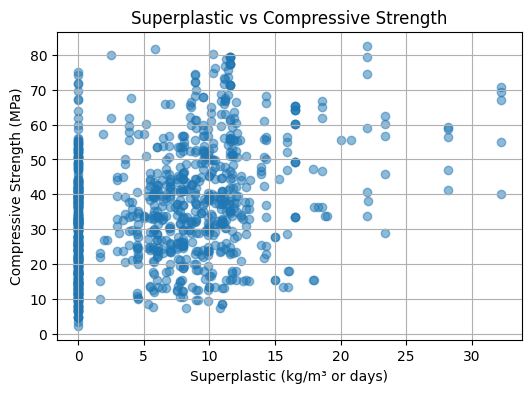

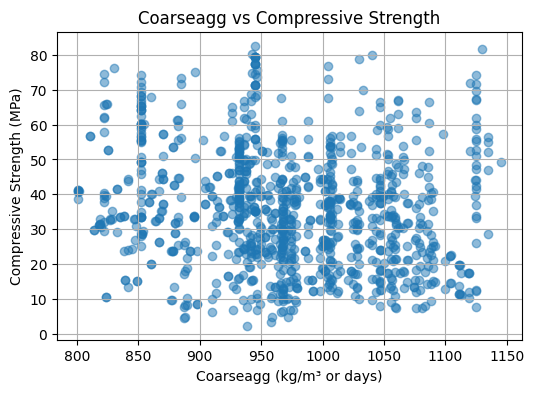

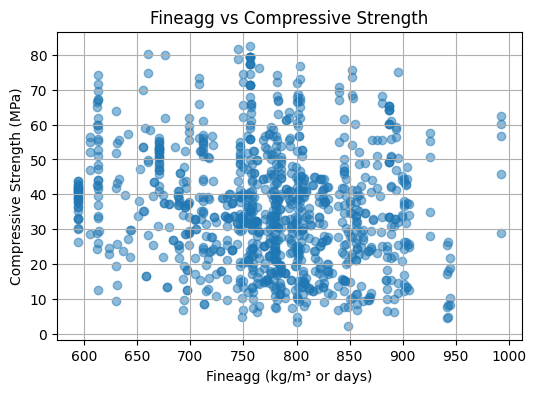

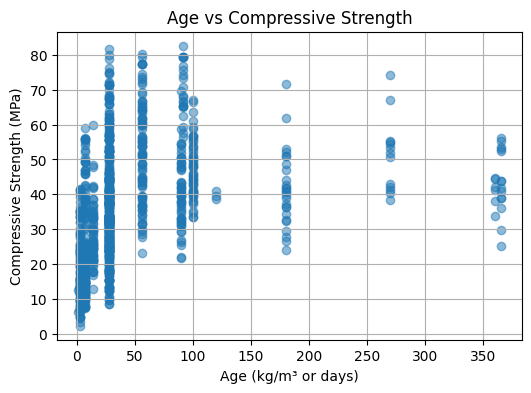

In [12]:
# CODE FOR ALL THE GRAPHS TOGETHER
import pandas as pd
import matplotlib.pyplot as plt
url="https://drive.google.com/uc?id=1XnQHdX3sF1bJWCEWJufuY8qOPxAL1Xtq"
df=pd.read_csv(url)

components = ['water', 'superplastic', 'coarseagg', 'fineagg', 'age']

for comp in components:
    plt.figure(figsize=(6,4))
    plt.scatter(df[comp], df['strength'], alpha=0.5)
    plt.xlabel(f'{comp.capitalize()} (kg/m³ or days)')
    plt.ylabel('Compressive Strength (MPa)')
    plt.title(f'{comp.capitalize()} vs Compressive Strength')
    plt.grid(True)
    plt.show()

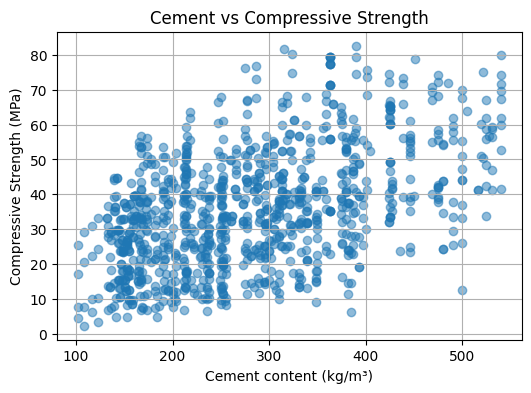

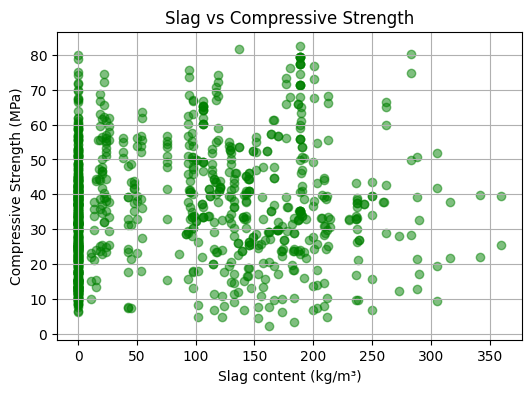

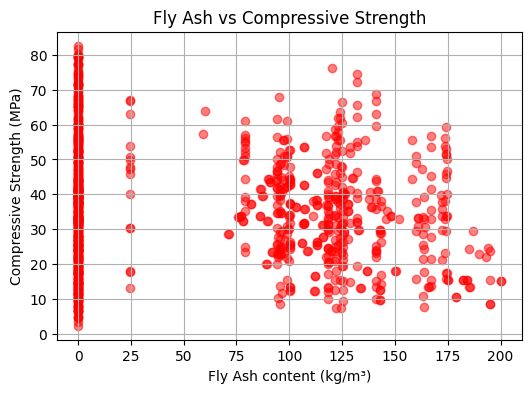

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
url="https://drive.google.com/uc?id=1XnQHdX3sF1bJWCEWJufuY8qOPxAL1Xtq"
df=pd.read_csv(url)

# 1. Cement content vs Compressive Strength (scatter plot)
plt.figure(figsize=(6,4))
plt.scatter(df['cement'], df['strength'], alpha=0.5)
plt.xlabel('Cement content (kg/m³)')
plt.ylabel('Compressive Strength (MPa)')
plt.title('Cement vs Compressive Strength')
plt.grid(True)
plt.show()

# 2. Slag content vs Compressive Strength (scatter plot)
plt.figure(figsize=(6,4))
plt.scatter(df['slag'], df['strength'], alpha=0.5, color='green')
plt.xlabel('Slag content (kg/m³)')
plt.ylabel('Compressive Strength (MPa)')
plt.title('Slag vs Compressive Strength')
plt.grid(True)
plt.show()

# 3. Fly Ash content vs Compressive Strength (scatter plot)
plt.figure(figsize=(6,4))
plt.scatter(df['ash'], df['strength'], alpha=0.5, color='red')
plt.xlabel('Fly Ash content (kg/m³)')
plt.ylabel('Compressive Strength (MPa)')
plt.title('Fly Ash vs Compressive Strength')
plt.grid(True)
plt.show()

The model successfully predicts cement strength based on input features and can be used to identify optimal compositions.

This project demonstrates the application of machine learning in real-world engineering problems.